# Fall Detection — Configuration 01: Real ADLs Baseline

This notebook establishes the **1D CNN baseline** for **Configuration 01 (Real ADLs only)**
of the multimodal fall-detection classification experiment.

**Task:** Binary classification — `FALL` (1) vs `NON_FALL` (0) — on synchronized
IMU + Infrared + Radar time-series windows of shape `(32 time frames, 1137 features)`.

**Scope of this notebook:** Configuration 01 only (real data, no synthetic/generated samples).
The pipeline, split strategy, and CNN architecture are kept consistent with the planned
Configuration 02 and Configuration 03 notebooks, so results are comparable across configs.

**Pipeline:**
1. Load dataset
2. Dataset / metadata sanity checks
3. Subject-wise Train / Validation / Test split
4. Preprocessing / normalization (fit on TRAIN only)
5. Prepare model input
6. Define 1D CNN
7. Train
8. Validate (training curves)
9. Evaluate on the REAL test set
10. Save model and results


## 0. Configuration

All paths, hyperparameters, and reproducibility settings live here so the notebook is easy to adapt and reproduce.

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Paths (edit these to match your environment)
# ---------------------------------------------------------------------------
CONFIG_NAME   = "01-Real_ADLs"
DATA_ROOT     = os.path.join("Classification_Datasets", CONFIG_NAME)
NPY_PATH      = os.path.join(DATA_ROOT, "features.npy")      # <-- adjust filename if different
METADATA_PATH = os.path.join(DATA_ROOT, "metadata.csv")      # <-- adjust filename if different

OUTPUT_DIR = os.path.join("Results", CONFIG_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------------
# Split configuration (subject-wise)
# ---------------------------------------------------------------------------
N_TEST_SUBJECTS = 2   # subjects held out for the final REAL test set
N_VAL_SUBJECTS  = 2   # subjects held out for validation
# Remaining subjects (10 - 2 - 2 = 6) are used for training

# ---------------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------------
BATCH_SIZE     = 32
MAX_EPOCHS     = 200
LEARNING_RATE  = 1e-3
EARLY_STOP_PATIENCE = 20
LR_PATIENCE    = 8
LR_FACTOR      = 0.5
DROPOUT_RATE   = 0.3

print("Configuration loaded.")
print(f"  Config name : {CONFIG_NAME}")
print(f"  NPY path    : {NPY_PATH}")
print(f"  Metadata    : {METADATA_PATH}")
print(f"  Output dir  : {OUTPUT_DIR}")
print(f"  Seed        : {SEED}")


Configuration loaded.
  Config name : 01-Real_ADLs
  NPY path    : Classification_Datasets\01-Real_ADLs\features.npy
  Metadata    : Classification_Datasets\01-Real_ADLs\metadata.csv
  Output dir  : Results\01-Real_ADLs
  Seed        : 42


## 1. Load Dataset

Load the `.npy` feature array and the metadata `.csv`, and verify they are aligned
(`len(X) == len(metadata)`) before doing anything else.

In [2]:
import os
import numpy as np
import pandas as pd

# --- Paths ---------------------------------------------------------------
BASE_DIR = r"C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model"
DATASET_DIR = os.path.join(BASE_DIR, "Classification_Datasets", "01-Real_ADLs")

NPY_PATH = os.path.join(DATASET_DIR, "X_imu_radar.npy")
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")

# --- Existence checks ----------------------------------------------------
assert os.path.exists(NPY_PATH), f"NPY file not found: {NPY_PATH}"
assert os.path.exists(METADATA_PATH), f"Metadata file not found: {METADATA_PATH}"

# --- Load ----------------------------------------------------------------
X_all = np.load(NPY_PATH)
metadata = pd.read_csv(METADATA_PATH)

# --- Info ----------------------------------------------------------------
print("Dataset path   :", NPY_PATH)
print("Metadata path  :", METADATA_PATH)
print("Array shape    :", X_all.shape)
print("Array dtype    :", X_all.dtype)
print("Metadata rows  :", len(metadata))
print("Num samples    :", X_all.shape[0])
print("Time frames    :", X_all.shape[1])
print("Num features   :", X_all.shape[2])

# --- Hard alignment check ------------------------------------------------
if len(X_all) != len(metadata):
    raise ValueError(
        f"Alignment error: len(X)={len(X_all)} != len(metadata)={len(metadata)}. "
        "Stopping — do not proceed with misaligned data."
    )
print("\n[OK] Array and metadata are aligned:", len(X_all), "==", len(metadata))

Dataset path   : C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model\Classification_Datasets\01-Real_ADLs\X_imu_radar.npy
Metadata path  : C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model\Classification_Datasets\01-Real_ADLs\metadata.csv
Array shape    : (1014, 32, 1137)
Array dtype    : float32
Metadata rows  : 1014
Num samples    : 1014
Time frames    : 32
Num features   : 1137

[OK] Array and metadata are aligned: 1014 == 1014


## 2. Dataset & Metadata Sanity Checks

We re-verify everything the inspection script reported (unique sample IDs, label validity,
class counts, subject distribution, missingness, NaN/Inf) directly against the loaded
arrays, rather than trusting the earlier report blindly.

In [3]:
print("=" * 70)
print("SANITY CHECKS — Configuration 01: Real ADLs")
print("=" * 70)

# --- Expected columns -----------------------------------------------------
expected_cols = [
    "sample_id", "label", "subject_id", "fall_id", "fall_number",
    "segment_id", "center_time", "window_start", "window_end",
    "original_frame_count", "target_frames", "feature_count",
]
missing_cols = [c for c in expected_cols if c not in metadata.columns]
if missing_cols:
    raise ValueError(f"Missing expected metadata columns: {missing_cols}")
print("[OK] All expected metadata columns are present.")

# --- Unique sample_id -------------------------------------------------------
n_unique_ids = metadata["sample_id"].nunique()
assert n_unique_ids == len(metadata), (
    f"sample_id is not unique: {n_unique_ids} unique vs {len(metadata)} rows"
)
print(f"[OK] sample_id is unique ({n_unique_ids} values).")

# --- Valid labels ------------------------------------------------------------
valid_labels = {"FALL", "NON_FALL"}
found_labels = set(metadata["label"].unique())
assert found_labels.issubset(valid_labels), f"Unexpected label values: {found_labels}"
print(f"[OK] Labels are valid: {found_labels}")

# --- Class distribution -------------------------------------------------
label_counts = metadata["label"].value_counts()
label_pct = metadata["label"].value_counts(normalize=True) * 100
print("\nClass distribution:")
for lbl in label_counts.index:
    print(f"  {lbl:10s}: {label_counts[lbl]:5d} ({label_pct[lbl]:5.2f}%)")

# --- Subject distribution -----------------------------------------------
subject_counts = metadata["subject_id"].value_counts().sort_index()
print("\nSubject distribution:")
print(subject_counts.to_string())

# --- FALL / NON_FALL per subject -----------------------------------------
per_subject = pd.crosstab(metadata["subject_id"], metadata["label"])
print("\nFALL / NON_FALL per subject:")
print(per_subject)

# --- Missing values -------------------------------------------------------
missing = metadata.isna().sum()
missing = missing[missing > 0]
print("\nMissing values per column:")
if len(missing) == 0:
    print("  (none)")
else:
    print(missing.to_string())
print("\nNote: fall_id / fall_number are expected to be NaN for NON_FALL rows — this is normal.")

# --- NaN / Inf in the feature array --------------------------------------
n_nan = np.isnan(X_all).sum()
n_inf = np.isinf(X_all).sum()
print(f"\nNaN values in X_all: {n_nan}")
print(f"Inf values in X_all: {n_inf}")
if n_nan > 0 or n_inf > 0:
    raise ValueError(
        f"Data quality issue: {n_nan} NaNs and {n_inf} Infs found in the feature array. "
        "Investigate before proceeding."
    )
print("[OK] No NaN or Inf values in the feature array.")

# --- Shape checks -----------------------------------------------------------
n_samples, n_frames, n_features = X_all.shape
assert (metadata["target_frames"] == n_frames).all(), "target_frames mismatch with array shape"
assert (metadata["feature_count"] == n_features).all(), "feature_count mismatch with array shape"
print(f"[OK] Shape consistent with metadata: samples={n_samples}, frames={n_frames}, features={n_features}")

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total samples : {n_samples}")
print(f"Time frames   : {n_frames}")
print(f"Features      : {n_features}")
print(f"FALL          : {label_counts.get('FALL', 0)} ({label_pct.get('FALL', 0):.2f}%)")
print(f"NON_FALL      : {label_counts.get('NON_FALL', 0)} ({label_pct.get('NON_FALL', 0):.2f}%)")
print(f"Subjects      : {metadata['subject_id'].nunique()}")


SANITY CHECKS — Configuration 01: Real ADLs
[OK] All expected metadata columns are present.
[OK] sample_id is unique (1014 values).
[OK] Labels are valid: {'FALL', 'NON_FALL'}

Class distribution:
  NON_FALL  :   915 (90.24%)
  FALL      :    99 ( 9.76%)

Subject distribution:
subject_id
1     172
2      96
3     115
4      93
5      96
6      91
7      86
8      83
9      71
10    111

FALL / NON_FALL per subject:
label       FALL  NON_FALL
subject_id                
1             10       162
2             10        86
3              9       106
4             10        83
5             10        86
6             10        81
7             10        76
8             10        73
9             10        61
10            10       101

Missing values per column:
fall_id        915
fall_number    915

Note: fall_id / fall_number are expected to be NaN for NON_FALL rows — this is normal.

NaN values in X_all: 0
Inf values in X_all: 0
[OK] No NaN or Inf values in the feature array.
[OK] Sha

## 3. Subject-Wise Train / Validation / Test Split

**Why subject-wise?** Windows from the same subject are highly correlated (similar gait,
body dimensions, sensor placement). A random sample-wise split would let the model see
windows from the same subject in both train and test, inflating performance and hiding
poor generalization to *new* people — which is the clinically relevant scenario.

We therefore split at the **`subject_id`** level: each subject's windows go entirely into
exactly one of TRAIN / VALIDATION / TEST. We search over candidate subject partitions and
pick one that keeps a reasonable FALL/NON_FALL balance in every split, since with only
10 subjects and 99 FALL samples an arbitrary partition can easily starve a split of the
positive class.

In [4]:
subject_summary = per_subject.copy()
subject_summary["Total"] = subject_summary.sum(axis=1)
subject_summary["FALL_pct"] = 100 * subject_summary.get("FALL", 0) / subject_summary["Total"]
print("Per-subject candidate summary:")
print(subject_summary)

all_subjects = sorted(metadata["subject_id"].unique().tolist())
n_subjects = len(all_subjects)
n_test = N_TEST_SUBJECTS
n_val = N_VAL_SUBJECTS
n_train = n_subjects - n_test - n_val
assert n_train > 0, "Not enough subjects left for training after val/test allocation."

print(f"\nSubjects: {n_subjects} total -> train={n_train}, val={n_val}, test={n_test}")

rng = random.Random(SEED)

def fall_fraction(subj_ids):
    sub = metadata[metadata["subject_id"].isin(subj_ids)]
    if len(sub) == 0:
        return 0.0
    return (sub["label"] == "FALL").mean()

overall_fall_frac = (metadata["label"] == "FALL").mean()

best_partition = None
best_score = None
N_TRIALS = 2000
subjects_list = all_subjects[:]

for _ in range(N_TRIALS):
    shuffled = subjects_list[:]
    rng.shuffle(shuffled)
    test_subj = sorted(shuffled[:n_test])
    val_subj = sorted(shuffled[n_test:n_test + n_val])
    train_subj = sorted(shuffled[n_test + n_val:])

    # Every split must contain at least one FALL sample
    fracs = [fall_fraction(train_subj), fall_fraction(val_subj), fall_fraction(test_subj)]
    if any(f == 0.0 for f in fracs):
        continue

    # Score: how close each split's FALL fraction is to the overall FALL fraction
    score = sum(abs(f - overall_fall_frac) for f in fracs)
    if best_score is None or score < best_score:
        best_score = score
        best_partition = (train_subj, val_subj, test_subj)

assert best_partition is not None, "Could not find a subject partition with FALL samples in every split."
train_subjects, val_subjects, test_subjects = best_partition

print("\nSelected subject-wise split (seed =", SEED, "):")
print("  TRAIN subjects     :", train_subjects)
print("  VALIDATION subjects:", val_subjects)
print("  TEST subjects      :", test_subjects)


Per-subject candidate summary:
label       FALL  NON_FALL  Total   FALL_pct
subject_id                                  
1             10       162    172   5.813953
2             10        86     96  10.416667
3              9       106    115   7.826087
4             10        83     93  10.752688
5             10        86     96  10.416667
6             10        81     91  10.989011
7             10        76     86  11.627907
8             10        73     83  12.048193
9             10        61     71  14.084507
10            10       101    111   9.009009

Subjects: 10 total -> train=6, val=2, test=2

Selected subject-wise split (seed = 42 ):
  TRAIN subjects     : [1, 2, 5, 6, 7, 9]
  VALIDATION subjects: [4, 10]
  TEST subjects      : [3, 8]


In [5]:
# --- Disjointness checks ---------------------------------------------------
train_set, val_set, test_set = set(train_subjects), set(val_subjects), set(test_subjects)
assert train_set.isdisjoint(val_set), "TRAIN and VALIDATION subjects overlap!"
assert train_set.isdisjoint(test_set), "TRAIN and TEST subjects overlap!"
assert val_set.isdisjoint(test_set), "VALIDATION and TEST subjects overlap!"
print("[OK] TRAIN / VALIDATION / TEST subjects are mutually disjoint.")

# --- Build split masks -------------------------------------------------------
train_mask = metadata["subject_id"].isin(train_subjects).values
val_mask   = metadata["subject_id"].isin(val_subjects).values
test_mask  = metadata["subject_id"].isin(test_subjects).values

assert (train_mask | val_mask | test_mask).all(), "Some rows were not assigned to any split."
assert not (train_mask & val_mask).any(), "Row assigned to both TRAIN and VAL."
assert not (train_mask & test_mask).any(), "Row assigned to both TRAIN and TEST."
assert not (val_mask & test_mask).any(), "Row assigned to both VAL and TEST."

def split_summary(name, mask):
    sub_meta = metadata[mask]
    n = len(sub_meta)
    n_fall = (sub_meta["label"] == "FALL").sum()
    n_nonfall = (sub_meta["label"] == "NON_FALL").sum()
    print(f"\n{name} split:")
    print(f"  Samples   : {n}")
    print(f"  FALL      : {n_fall} ({100*n_fall/n:.2f}%)")
    print(f"  NON_FALL  : {n_nonfall} ({100*n_nonfall/n:.2f}%)")
    subj_list = sorted(sub_meta["subject_id"].unique().tolist())
    print(f"  Subjects  : {subj_list}")

split_summary("TRAIN", train_mask)
split_summary("VALIDATION", val_mask)
split_summary("TEST", test_mask)

# --- Persist split for reproducibility --------------------------------------
split_info = {
    "seed": SEED,
    "train_subjects": train_subjects,
    "val_subjects": val_subjects,
    "test_subjects": test_subjects,
    "train_sample_ids": metadata.loc[train_mask, "sample_id"].tolist(),
    "val_sample_ids": metadata.loc[val_mask, "sample_id"].tolist(),
    "test_sample_ids": metadata.loc[test_mask, "sample_id"].tolist(),
}
split_path = os.path.join(OUTPUT_DIR, "config01_split.json")
with open(split_path, "w") as f:
    json.dump(split_info, f, indent=2)
print(f"\n[Saved] Split metadata -> {split_path}")


[OK] TRAIN / VALIDATION / TEST subjects are mutually disjoint.

TRAIN split:
  Samples   : 612
  FALL      : 60 (9.80%)
  NON_FALL  : 552 (90.20%)
  Subjects  : [1, 2, 5, 6, 7, 9]

VALIDATION split:
  Samples   : 204
  FALL      : 20 (9.80%)
  NON_FALL  : 184 (90.20%)
  Subjects  : [4, 10]

TEST split:
  Samples   : 198
  FALL      : 19 (9.60%)
  NON_FALL  : 179 (90.40%)
  Subjects  : [3, 8]

[Saved] Split metadata -> Results\01-Real_ADLs\config01_split.json


## 4. Preprocessing / Normalization

**Leakage rule:** normalization statistics are fit **only on TRAIN**, then applied
unchanged to VALIDATION and TEST. Fitting on the full dataset (or on val/test) would leak
information about the held-out subjects into training, invalidating the generalization
test the subject-wise split is designed to provide.

**Strategy:** per-feature z-score standardization (mean/std computed over the TRAIN
`(samples × time frames)` axis, per feature channel). This preserves the `(N, 32, 1137)`
temporal structure — we do **not** flatten samples — and is a sensible default for
multimodal sensor data where different channels (IMU / IR / radar) can have very
different scales; per-feature standardization puts every channel on a comparable scale
without mixing information across channels or time steps.

In [6]:
X_train_raw = X_all[train_mask]
X_val_raw   = X_all[val_mask]
X_test_raw  = X_all[test_mask]

y_train_raw = metadata.loc[train_mask, "label"].values
y_val_raw   = metadata.loc[val_mask, "label"].values
y_test_raw  = metadata.loc[test_mask, "label"].values

print("Raw shapes:")
print("  X_train:", X_train_raw.shape, " X_val:", X_val_raw.shape, " X_test:", X_test_raw.shape)

# --- Fit per-feature mean/std on TRAIN only ---------------------------------
# Reshape to (samples * time_frames, features) to compute per-feature stats,
# but only using TRAIN data.
train_flat_for_stats = X_train_raw.reshape(-1, X_train_raw.shape[-1])
feature_mean = train_flat_for_stats.mean(axis=0)
feature_std = train_flat_for_stats.std(axis=0)
feature_std[feature_std == 0] = 1.0  # guard against constant features

def normalize(X, mean, std):
    return (X - mean) / std

X_train = normalize(X_train_raw, feature_mean, feature_std)
X_val   = normalize(X_val_raw, feature_mean, feature_std)
X_test  = normalize(X_test_raw, feature_mean, feature_std)

print("\n[OK] Normalization fit on TRAIN only and applied to TRAIN/VAL/TEST.")
print("Post-normalization TRAIN mean (~0):", np.round(X_train.mean(), 4))
print("Post-normalization TRAIN std  (~1):", np.round(X_train.std(), 4))

# --- Save normalization parameters ------------------------------------------
norm_path = os.path.join(OUTPUT_DIR, "config01_normalization.npz")
np.savez(norm_path, mean=feature_mean, std=feature_std)
print(f"[Saved] Normalization parameters -> {norm_path}")


Raw shapes:
  X_train: (612, 32, 1137)  X_val: (204, 32, 1137)  X_test: (198, 32, 1137)

[OK] Normalization fit on TRAIN only and applied to TRAIN/VAL/TEST.
Post-normalization TRAIN mean (~0): -0.0
Post-normalization TRAIN std  (~1): 0.926
[Saved] Normalization parameters -> Results\01-Real_ADLs\config01_normalization.npz


## 5. Prepare Model Input

Encode labels as binary integers (`NON_FALL=0`, `FALL=1`), confirm final shapes and class
distribution per split, and compute class weights **from TRAIN only** to counter the
~90/10 class imbalance. We use class weighting (not oversampling/duplication) as the
initial imbalance-handling strategy, since it doesn't distort the real data distribution
or risk overfitting to duplicated FALL windows.

In [7]:
label_map = {"NON_FALL": 0, "FALL": 1}
y_train = np.array([label_map[l] for l in y_train_raw], dtype=np.int32)
y_val   = np.array([label_map[l] for l in y_val_raw], dtype=np.int32)
y_test  = np.array([label_map[l] for l in y_test_raw], dtype=np.int32)

print("Final input shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("  X_test :", X_test.shape,  " y_test :", y_test.shape)

for name, y in [("TRAIN", y_train), ("VAL", y_val), ("TEST", y_test)]:
    n = len(y)
    n_fall = int(y.sum())
    print(f"\n{name} class distribution: FALL={n_fall} ({100*n_fall/n:.2f}%), "
          f"NON_FALL={n - n_fall} ({100*(n - n_fall)/n:.2f}%)")

# --- Class weights from TRAIN only ------------------------------------------
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weight_values)}
print("\nClass weights (computed from TRAIN only):", class_weights)


Final input shapes:
  X_train: (612, 32, 1137)  y_train: (612,)
  X_val  : (204, 32, 1137)  y_val  : (204,)
  X_test : (198, 32, 1137)  y_test : (198,)

TRAIN class distribution: FALL=60 (9.80%), NON_FALL=552 (90.20%)

VAL class distribution: FALL=20 (9.80%), NON_FALL=184 (90.20%)

TEST class distribution: FALL=19 (9.60%), NON_FALL=179 (90.40%)

Class weights (computed from TRAIN only): {0: 0.5543478260869565, 1: 5.1}


## 6. Model: 1D CNN

A simple 1D CNN is well-suited to this `(32, 1137)` input: convolutions along the time
axis let the network learn short local temporal patterns (e.g. the acceleration/impact
signature of a fall) shared across the 1137 feature channels, while global average
pooling makes the classifier robust to the exact temporal position of that pattern
within the 32-frame window. The architecture is deliberately kept simple — no attention,
recurrence, or residual blocks — since this experiment is about comparing dataset
configurations, not architecture search.

In [8]:
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

L2 = 1e-4  # L2 weight regularization strength

def build_model(input_shape, dropout_rate=DROPOUT_RATE, seed=SEED):
    inputs = layers.Input(shape=input_shape, name="input")

    x = layers.Conv1D(64, kernel_size=3, padding="same",
                       kernel_regularizer=regularizers.l2(L2), name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.SpatialDropout1D(dropout_rate * 0.5, name="sdrop1")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same",
                       kernel_regularizer=regularizers.l2(L2), name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.SpatialDropout1D(dropout_rate * 0.5, name="sdrop2")(x)

    x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = layers.Dense(32, activation="relu",
                      kernel_regularizer=regularizers.l2(L2), name="dense1")(x)
    x = layers.Dropout(dropout_rate, seed=seed, name="dropout")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    return models.Model(inputs=inputs, outputs=outputs, name="fall_cnn_1d")

input_shape = (X_train.shape[1], X_train.shape[2])  # (32, 1137)
print(f"Input shape: {input_shape}")

# Build one throwaway instance just to print architecture / param count.
# Each seed in the ensembling cell below builds and compiles its own fresh copy.
_preview = build_model(input_shape)
_preview.summary()
n_trainable = int(np.sum([np.prod(v.shape) for v in _preview.trainable_weights]))
print(f"\nTrainable parameters (per seed model): {n_trainable:,}")
del _preview


Input shape: (32, 1137)


Model: "fall_cnn_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 1137)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 32, 64)         │       218,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop1 (SpatialDropout1D)       │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop2 (SpatialDropout1D)       │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,001 (968.75 KB)

 Trainable params: 247,617 (967.25 KB)

 Non-trainable params: 384 (1.50 KB)


Trainable parameters (per seed model): 247,617


## 7. Training

Trained with Adam + binary cross-entropy, TRAIN-only class weights, early stopping on
validation loss, checkpointing of the best model, and a learning-rate reduction on
plateau. The validation set only monitors training progress — it plays no role in fitting
the normalization statistics (Section 4) and is not touched during evaluation (Section 9).

In [9]:
SEEDS = [42, 101, 202, 303, 404]

val_probs_all, test_probs_all, histories_all = [], [], []

for s in SEEDS:
    tf.random.set_seed(s)
    m = build_model(input_shape, seed=s)
    m.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=0,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=LR_FACTOR, patience=LR_PATIENCE,
            min_lr=1e-6, verbose=0,
        ),
    ]

    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=cb,
        verbose=0,
    )

    val_probs_all.append(m.predict(X_val, batch_size=BATCH_SIZE).ravel())
    test_probs_all.append(m.predict(X_test, batch_size=BATCH_SIZE).ravel())
    histories_all.append({k: [float(v) for v in vals] for k, vals in h.history.items()})
    print(f"[seed {s}] done -- best val_loss = {min(h.history['val_loss']):.4f}")

# Ensembled probabilities (averaged across seeds) -- these feed the threshold-tuning
# cell and the final evaluation cell below.
y_val_prob  = np.mean(val_probs_all, axis=0)
y_test_prob = np.mean(test_probs_all, axis=0)
print(f"\n[Ensembling] Averaged predictions across {len(SEEDS)} seeds.")

history_path = os.path.join(OUTPUT_DIR, "config01_history_per_seed.json")
with open(history_path, "w") as f:
    json.dump({str(s): h for s, h in zip(SEEDS, histories_all)}, f, indent=2)
print(f"[Saved] Per-seed training history -> {history_path}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[seed 42] done -- best val_loss = 0.0344
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[seed 101] done -- best val_loss = 0.0462
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[seed 202] done -- best val_loss = 0.0403
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[seed 303] done -- best val_loss = 0.0423
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[seed 404] done -- best val_loss = 0.0470

[Ensembling] Averaged predictions across 5 seeds.
[Saved] Per-seed training history -> Results\01-Real_ADLs\config01_history_per_seed.json


In [10]:
# --- Threshold tuning on VALIDATION only (never touches test; uses ensembled y_val_prob) ---
from sklearn.metrics import f1_score, precision_recall_curve

prec_v, rec_v, thresh_v = precision_recall_curve(y_val, y_val_prob)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)

# Primary rule: threshold that maximizes F1 on VAL
best_idx = int(np.nanargmax(f1_v[:-1]))          # last PR point has no matching threshold
best_threshold = float(thresh_v[best_idx])

print(f"[Threshold] Max-F1 on VAL: {best_threshold:.4f} "
      f"(VAL precision={prec_v[best_idx]:.3f}, recall={rec_v[best_idx]:.3f}, f1={f1_v[best_idx]:.3f})")

# Optional alternative: highest precision subject to recall >= 0.90.
# Uncomment if you'd rather not miss falls than reduce false alarms.
# recall_floor_mask = rec_v >= 0.90
# if recall_floor_mask.any():
#     alt_idx = int(np.argmax(prec_v[recall_floor_mask]))
#     best_threshold = float(thresh_v[:-1][recall_floor_mask][alt_idx])
#     print(f"[Threshold] Recall-floor(0.90) on VAL: {best_threshold:.4f} "
#           f"(VAL precision={prec_v[recall_floor_mask][alt_idx]:.3f}, "
#           f"recall={rec_v[recall_floor_mask][alt_idx]:.3f})")


[Threshold] Max-F1 on VAL: 0.6766 (VAL precision=0.952, recall=1.000, f1=0.976)


## 8. Training Curves

Loss and accuracy over epochs, TRAIN vs VALIDATION. These curves describe optimization
behavior only — they are **not** a substitute for the held-out test evaluation in
Section 9.

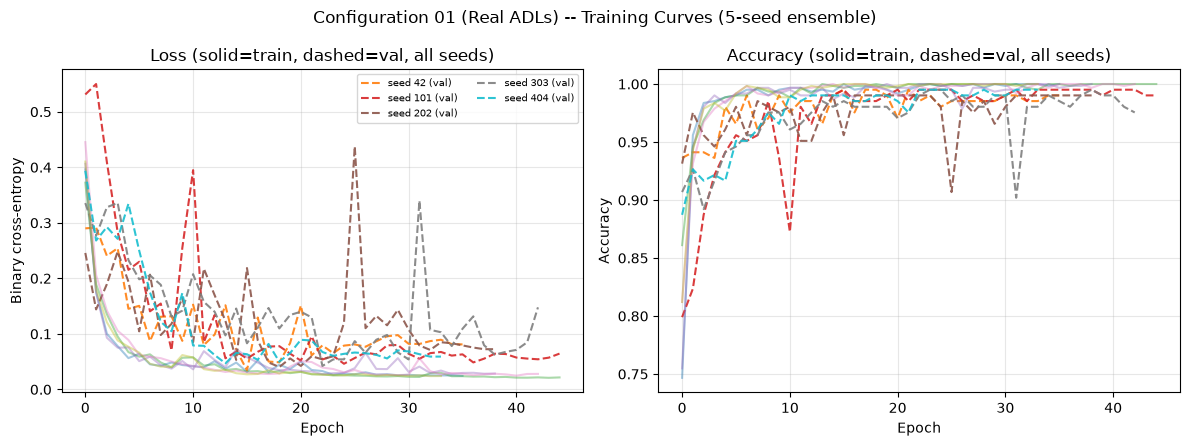

[Saved] Training curves -> Results\01-Real_ADLs\config01_training_curves.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for s, h in zip(SEEDS, histories_all):
    axes[0].plot(h["loss"], alpha=0.4)
    axes[0].plot(h["val_loss"], alpha=0.9, linestyle="--", label=f"seed {s} (val)")
    axes[1].plot(h["accuracy"], alpha=0.4)
    axes[1].plot(h["val_accuracy"], alpha=0.9, linestyle="--")

axes[0].set_title("Loss (solid=train, dashed=val, all seeds)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].set_title("Accuracy (solid=train, dashed=val, all seeds)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

fig.suptitle("Configuration 01 (Real ADLs) -- Training Curves (5-seed ensemble)")
fig.tight_layout()

curves_path = os.path.join(OUTPUT_DIR, "config01_training_curves.png")
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] Training curves -> {curves_path}")


## 9. Final Evaluation on the REAL Test Set

The best checkpoint (selected by validation loss) is evaluated **once** on the held-out
test set, whose subjects were never seen during training or validation. Because the
classes are imbalanced and FALL is the clinically important class, we report a full set
of metrics beyond accuracy, with `FALL = positive class`, `NON_FALL = negative class`.

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)

# y_test_prob was already computed by the 5-seed ensembling cell above (averaged probabilities)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)   # Sensitivity
f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])  # rows/cols: [NON_FALL, FALL]
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
balanced_acc = (recall + specificity) / 2

print("=" * 60)
print("FINAL TEST SET EVALUATION -- Configuration 01 (Real ADLs)")
print("Positive class = FALL, Negative class = NON_FALL")
print("=" * 60)
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")

print("\nConfusion matrix (rows=true, cols=pred, order=[NON_FALL, FALL]):")
print(cm)

print("\nClassification report:")
report_str = classification_report(
    y_test, y_test_pred, target_names=["NON_FALL", "FALL"], zero_division=0
)
print(report_str)


FINAL TEST SET EVALUATION -- Configuration 01 (Real ADLs)
Positive class = FALL, Negative class = NON_FALL
Accuracy           : 0.9747
Precision          : 0.7917
Recall (Sensitivity): 1.0000
F1-score           : 0.8837
Specificity        : 0.9721
Balanced Accuracy  : 0.9860
ROC-AUC            : 0.9924
PR-AUC             : 0.8805

Confusion matrix (rows=true, cols=pred, order=[NON_FALL, FALL]):
[[174   5]
 [  0  19]]

Classification report:
              precision    recall  f1-score   support

    NON_FALL       1.00      0.97      0.99       179
        FALL       0.79      1.00      0.88        19

    accuracy                           0.97       198
   macro avg       0.90      0.99      0.93       198
weighted avg       0.98      0.97      0.98       198



In [13]:
# --- Bootstrap CI on TEST metrics (quantifies how much n=19 falls can wobble) -
rng = np.random.default_rng(SEED)
n_boot = 2000
idx = np.arange(len(y_test))
boot_f1, boot_rec, boot_prec = [], [], []

for _ in range(n_boot):
    sample = rng.choice(idx, size=len(idx), replace=True)
    if y_test[sample].sum() == 0:       # skip resamples with no FALL cases
        continue
    boot_f1.append(f1_score(y_test[sample], y_test_pred[sample], zero_division=0))
    boot_rec.append(recall_score(y_test[sample], y_test_pred[sample], zero_division=0))
    boot_prec.append(precision_score(y_test[sample], y_test_pred[sample], zero_division=0))

def ci(vals):
    return np.percentile(vals, [2.5, 97.5])

print(f"F1 95% CI        : [{ci(boot_f1)[0]:.3f}, {ci(boot_f1)[1]:.3f}]")
print(f"Recall 95% CI    : [{ci(boot_rec)[0]:.3f}, {ci(boot_rec)[1]:.3f}]")
print(f"Precision 95% CI : [{ci(boot_prec)[0]:.3f}, {ci(boot_prec)[1]:.3f}]")

F1 95% CI        : [0.759, 0.973]
Recall 95% CI    : [1.000, 1.000]
Precision 95% CI : [0.611, 0.947]


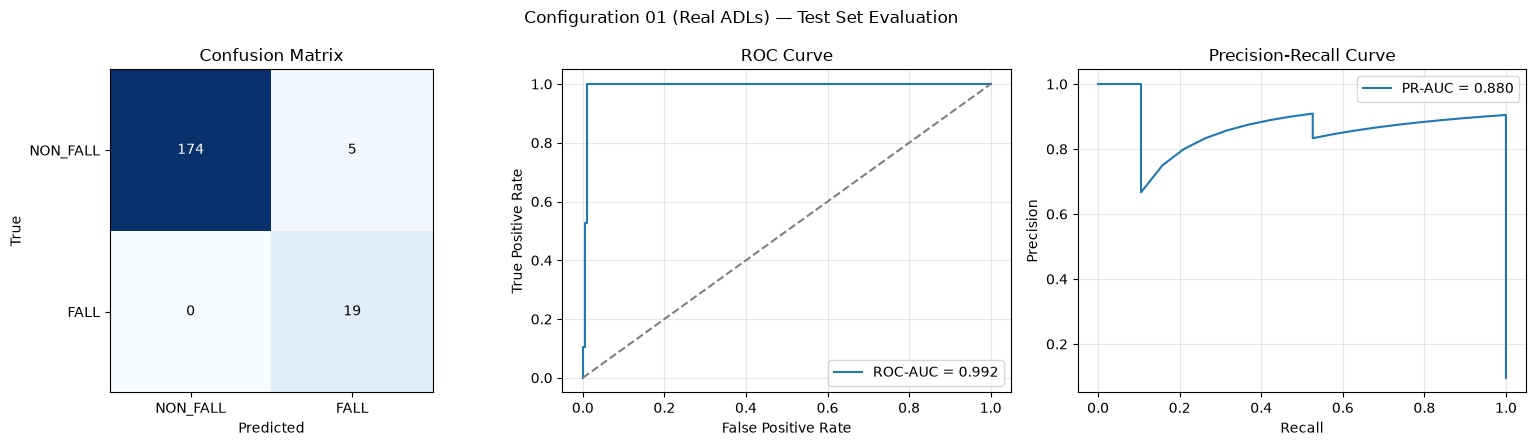

[Saved] Evaluation plots -> Results\01-Real_ADLs\config01_evaluation_plots.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["NON_FALL", "FALL"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["NON_FALL", "FALL"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_prob)
axes[2].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Configuration 01 (Real ADLs) — Test Set Evaluation")
fig.tight_layout()

eval_plot_path = os.path.join(OUTPUT_DIR, "config01_evaluation_plots.png")
fig.savefig(eval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] Evaluation plots -> {eval_plot_path}")


## 10. Save Model, Metrics, and Reproducibility Artifacts

In [15]:
# --- Confusion matrix -------------------------------------------------------
cm_path = os.path.join(OUTPUT_DIR, "config01_confusion_matrix.csv")
pd.DataFrame(cm, index=["true_NON_FALL", "true_FALL"],
             columns=["pred_NON_FALL", "pred_FALL"]).to_csv(cm_path)
print(f"[Saved] Confusion matrix -> {cm_path}")

# --- Classification report --------------------------------------------------
report_path = os.path.join(OUTPUT_DIR, "config01_classification_report.txt")
with open(report_path, "w") as f:
    f.write(report_str)
print(f"[Saved] Classification report -> {report_path}")

# --- Class weights ------------------------------------------------------------
cw_path = os.path.join(OUTPUT_DIR, "config01_class_weights.json")
with open(cw_path, "w") as f:
    json.dump(class_weights, f, indent=2)
print(f"[Saved] Class weights -> {cw_path}")

# --- Compact results CSV -----------------------------------------------------
results_row = {
    "config": CONFIG_NAME,
    "n_train": len(y_train),
    "n_val": len(y_val),
    "n_test": len(y_test),
    "accuracy": acc,
    "precision": precision,
    "recall_sensitivity": recall,
    "f1_score": f1,
    "specificity": specificity,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "seeds": str(SEEDS),
}
results_csv_path = os.path.join(OUTPUT_DIR, "config01_results.csv")
pd.DataFrame([results_row]).to_csv(results_csv_path, index=False)
print(f"[Saved] Compact results -> {results_csv_path}")

print("\n" + "=" * 60)
print("All Configuration 01 artifacts saved to:", OUTPUT_DIR)
print("=" * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)


[Saved] Confusion matrix -> Results\01-Real_ADLs\config01_confusion_matrix.csv
[Saved] Classification report -> Results\01-Real_ADLs\config01_classification_report.txt
[Saved] Class weights -> Results\01-Real_ADLs\config01_class_weights.json
[Saved] Compact results -> Results\01-Real_ADLs\config01_results.csv

All Configuration 01 artifacts saved to: Results\01-Real_ADLs
 - config01_class_weights.json
 - config01_classification_report.txt
 - config01_confusion_matrix.csv
 - config01_evaluation_plots.png
 - config01_history_per_seed.json
 - config01_normalization.npz
 - config01_results.csv
 - config01_split.json
 - config01_training_curves.png
